Task 1

In [7]:
%pip install opencv-python
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Dania\AppData\Roaming\Python\Python314\site-packages\pip\__main__.py", line 24, in <module>
  File "C:\Users\Dania\AppData\Roaming\Python\Python314\site-packages\pip\_internal\cli\main.py", line 47, in main
  File "C:\Users\Dania\AppData\Roaming\Python\Python314\site-packages\pip\_internal\cli\autocompletion.py", line 12, in <module>
  File "C:\Users\Dania\AppData\Roaming\Python\Python314\site-packages\pip\_internal\cli\main_parser.py", line 12, in <module>
  File "C:\Users\Dania\AppData\Roaming\Python\Python314\site-packages\pip\_internal\cli\cmdoptions.py", line 30, in <module>
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1342, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 938, in _load_unlocked
  File "<frozen importlib._bootstrap_exte

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------

In [8]:
import cv2
import matplotlib.pyplot as plt

# Validation script
print("OpenCV version:", cv2.__version__)
print("Matplotlib loaded successfully:", plt is not None)

OpenCV version: 4.13.0
Matplotlib loaded successfully: True


Task 2

In [9]:
class GroceryManager:
    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        self.items[item] = {'quantity': quantity, 'price': price}
        print(f"'{item}' added: {quantity} units @ Rs.{price} each")

    def remove_item(self, item):
        try:
            del self.items[item]
            print(f"'{item}' removed successfully.")
        except KeyError:
            print(f"Error: '{item}' doesn't exist in the grocery list.")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return
        print(f"{'Item':<15}{'Quantity':<10}{'Price':<10}")
        for item, details in self.items.items():
            print(f"{item:<15}{details['quantity']:<10}{details['price']:<10}")

    def calculate_total(self):
        total = sum(details['quantity'] * details['price'] for details in self.items.values())
        return total


manager = GroceryManager()
manager.add_item("Milk", 2, 250)
manager.add_item("Rice", 5, 180)
manager.add_item("Sugar", 1, 150)

manager.view_list()
print("Total Cost: Rs.", manager.calculate_total())

manager.remove_item("Rice")
manager.remove_item("Butter")   # doesnt exit , should give an error message

manager.view_list()

'Milk' added: 2 units @ Rs.250 each
'Rice' added: 5 units @ Rs.180 each
'Sugar' added: 1 units @ Rs.150 each
Item           Quantity  Price     
Milk           2         250       
Rice           5         180       
Sugar          1         150       
Total Cost: Rs. 1550
'Rice' removed successfully.
Error: 'Butter' doesn't exist in the grocery list.
Item           Quantity  Price     
Milk           2         250       
Sugar          1         150       


Task 3

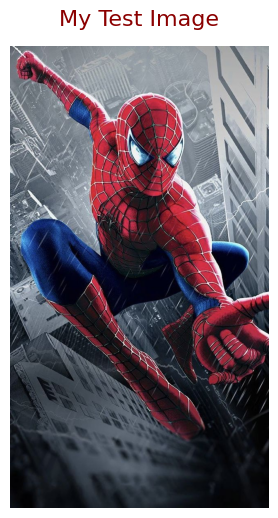

In [10]:
import cv2
import matplotlib.pyplot as plt

image_path = r'D:\Danias Code\CV\LAB 01\image.jpg'   
image = cv2.imread(image_path)

# Safety check
if image is None:
    print("Error: Image not found.")
else:

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.axis('off')

    plt.title('My Test Image', fontsize=16, color='darkred', pad=15)

    plt.imshow(image_rgb)
    plt.show()

Task 4

Center coordinates: (400, 400)


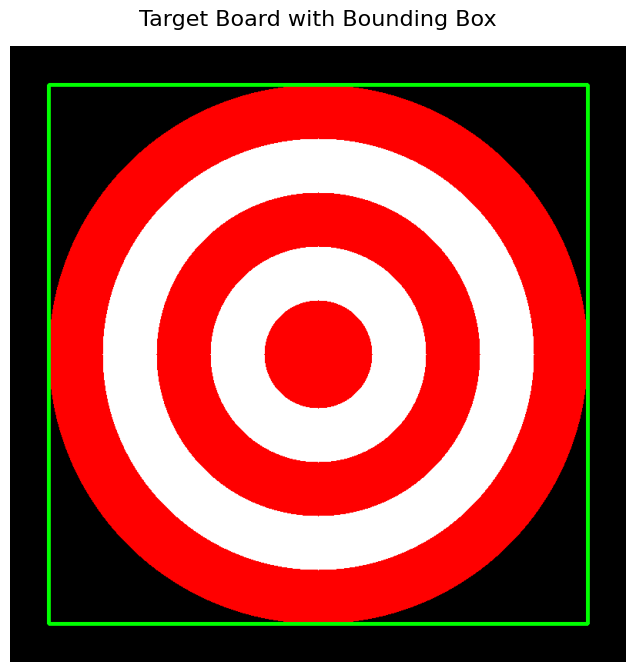

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

canvas = np.zeros((800, 800, 3), dtype=np.uint8)

center_x, center_y = canvas.shape[1] // 2, canvas.shape[0] // 2
print(f"Center coordinates: ({center_x}, {center_y})")

colors = [(255, 0, 0), (255, 255, 255), (255, 0, 0), (255, 255, 255), (255, 0, 0)]  
radii = [350, 280, 210, 140, 70]  # outermost to innermost

for radius, color in zip(radii, colors):
    cv2.circle(canvas, (center_x, center_y), radius, color, thickness=-1) 

outer_radius = radii[0]
top_left = (center_x - outer_radius, center_y - outer_radius)
bottom_right = (center_x + outer_radius, center_y + outer_radius)
cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), thickness=3)  # green bounding box

plt.figure(figsize=(8, 8))
plt.axis('off')
plt.title('Target Board with Bounding Box', fontsize=16, pad=15)
plt.imshow(canvas)
plt.show()

Task 5

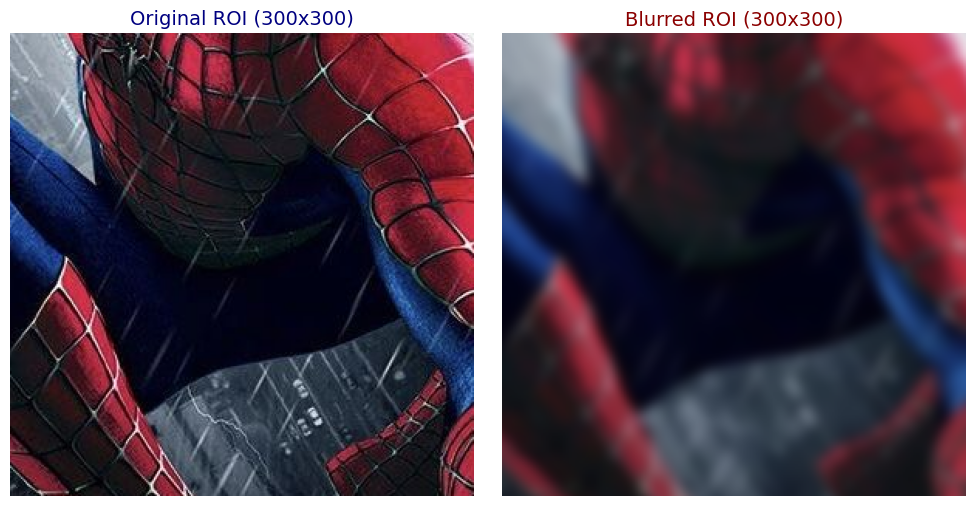

In [12]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('image.jpg')
if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_rgb = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    h, w = image_rgb.shape[:2]
    center_y, center_x = h // 2, w // 2

    half = 150
    original_roi = image_rgb[center_y-half:center_y+half, center_x-half:center_x+half]
    blurred_roi  = blurred_rgb[center_y-half:center_y+half, center_x-half:center_x+half]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_roi)
    axes[0].set_title('Original ROI (300x300)', fontsize=14, color='navy')
    axes[0].axis('off')

    axes[1].imshow(blurred_roi)
    axes[1].set_title('Blurred ROI (300x300)', fontsize=14, color='darkred')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Task 6

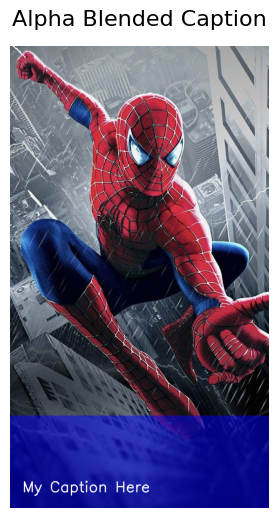

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('image.jpg')
if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    overlay = image_rgb.copy()

    box_start_y = int(h * 0.8)
    cv2.rectangle(overlay, (0, box_start_y), (w, h), (0, 0, 255), thickness=-1)  
    alpha = 0.5
    blended = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)

    
    cv2.putText(blended, "My Caption Here", (30, h - 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.title('Alpha Blended Caption', fontsize=16, pad=15)
    plt.imshow(blended)
    plt.show()

Task 7

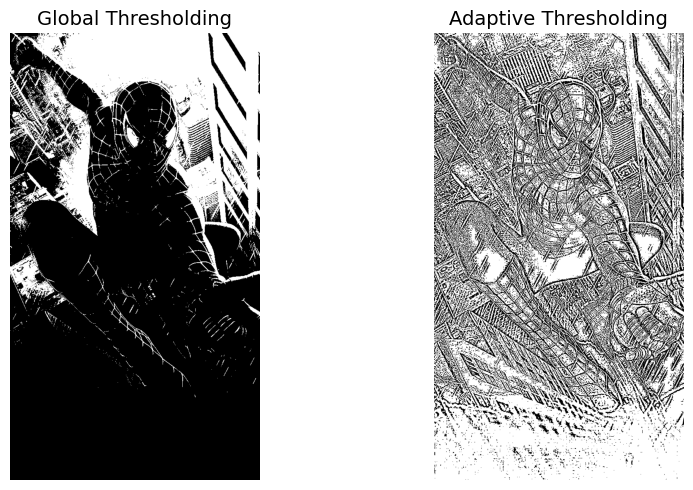

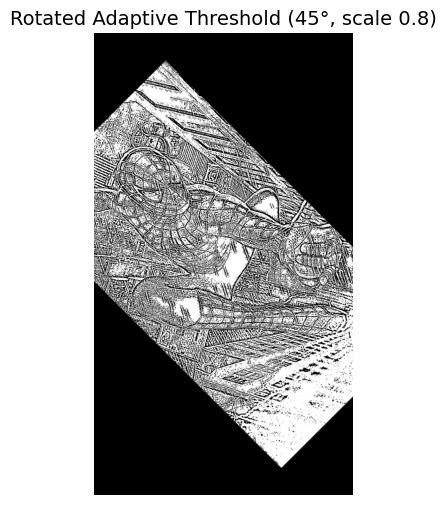

In [ ]:
import cv2
import matplotlib.pyplot as plt

gray_image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

if gray_image is None:
    print("Error: Image not found.")
else:
    _, global_thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

    adaptive_thresh = cv2.adaptiveThreshold(
        gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, blockSize=11, C=2
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].set_title('Global Thresholding', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].set_title('Adaptive Thresholding', fontsize=14)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    h, w = adaptive_thresh.shape[:2]
    center = (w / 2, h / 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)  # 45 deg, scale 0.8
    rotated = cv2.warpAffine(adaptive_thresh, rotation_matrix, (w, h))

    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.title('Rotated Adaptive Threshold (45°, scale 0.8)', fontsize=14)
    plt.imshow(rotated, cmap='gray')
    plt.show()

Task 8

<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dania\AppData\Local\Temp\ipykernel_22132\1362523566.py:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  img1 = cv2.imread('D:\Danias Code\CV\LAB 01\image.jpg')
C:\Users\Dania\AppData\Local\Temp\ipykernel_22132\1362523566.py:6: SyntaxWarning: "\D" is an invalid escape sequence

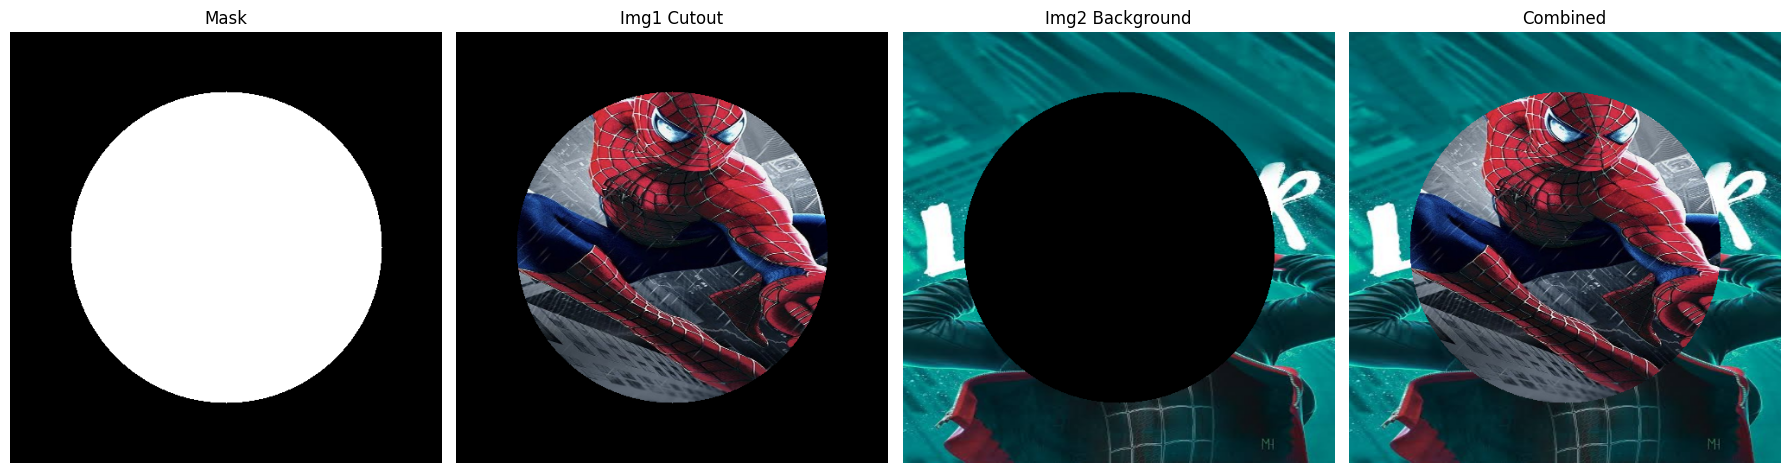

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('D:\Danias Code\CV\LAB 01\image.jpg')
img2 = cv2.imread('D:\Danias Code\CV\LAB 01\images.jpg')

if img1 is None or img2 is None:
    print("Error: One or both images not found.")
else:
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Resize both to exactly 500x500
    img1 = cv2.resize(img1, (500, 500))
    img2 = cv2.resize(img2, (500, 500))

    # Binary mask: black canvas with a thick white circle in center
    mask = np.zeros((500, 500), dtype=np.uint8)
    cv2.circle(mask, (250, 250), 180, 255, thickness=-1)

    # Step 1: bitwise_and -> cut the circle shape out of img1
    img1_cutout = cv2.bitwise_and(img1, img1, mask=mask)

    # Step 2: invert the mask, use it to cut out the background from img2
    inverted_mask = cv2.bitwise_not(mask)
    img2_background = cv2.bitwise_and(img2, img2, mask=inverted_mask)

    # Step 3: Combine both using bitwise_or
    combined = cv2.bitwise_or(img1_cutout, img2_background)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    titles = ['Mask', 'Img1 Cutout', 'Img2 Background', 'Combined']
    images = [mask, img1_cutout, img2_background, combined]
    cmaps = ['gray', None, None, None]

    for ax, img, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Task 9

In [16]:
import cv2
import pandas as pd

image = cv2.imread('D:\Danias Code\CV\LAB 01\image.jpg')
if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Flatten each channel into a 1D array
    red_channel   = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel  = image_rgb[:, :, 2].flatten()

    # Load into a Pandas DataFrame
    df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    # Statistical summary
    print("Statistical Summary of Image Pixel Values:")
    print(df.describe())

<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dania\AppData\Local\Temp\ipykernel_22132\1026623064.py:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  image = cv2.imread('D:\Danias Code\CV\LAB 01\image.jpg')


Statistical Summary of Image Pixel Values:
                 Red          Green           Blue
count  719590.000000  719590.000000  719590.000000
mean       87.490401      77.834927      89.457947
std        66.392560      62.509661      62.272175
min         0.000000       0.000000       0.000000
25%        26.000000      24.000000      34.000000
50%        77.000000      57.000000      75.000000
75%       143.000000     130.000000     142.000000
max       255.000000     255.000000     255.000000
